# Business Understanding

## Project Domain

Domain: Biologi Kelautan / Perikanan

Proyek ini berada dalam domain biologi kelautan, khususnya studi tentang abalone — sejenis moluska laut bernilai ekonomi tinggi. Penelitian usia abalone penting untuk pengelolaan sumber daya laut secara berkelanjutan dan pengaturan panen yang bertanggung jawab.



## Problem Statements

Masalah: Menentukan usia abalone secara tradisional memerlukan proses destruktif, yaitu memotong cangkang dan menghitung jumlah cincin menggunakan mikroskop. Metode ini tidak hanya merusak spesimen, tetapi juga tidak efisien untuk skala besar.



## Goals

Tujuan: Mengembangkan model prediktif berbasis fitur fisik abalone (seperti panjang, berat, dan jenis kelamin) untuk memperkirakan usia secara akurat dan non-destruktif, sehingga bisa digunakan dalam praktik pemantauan populasi.

## Solution Statements

Machine Learning Model
Menggunakan model Artificial Neural Network (ANN) untuk memprediksi usia abalone (dalam bentuk jumlah cincin) berdasarkan fitur fisik seperti panjang, berat, dan jenis kelamin.
Model dilatih untuk menghasilkan prediksi usia dengan akurasi tinggi dan error yang rendah (misalnya, RMSE < 2 cincin).

Aplikasi Web (Streamlit)
Membuat antarmuka pengguna berbasis web yang memungkinkan pengguna (peneliti atau petani laut) memasukkan data fisik abalone dan langsung mendapatkan estimasi usia abalone secara instan dan non-destruktif.

Optimasi dengan TensorFlow Lite
Model dikonversi ke format TFLite agar ringan dan dapat digunakan pada perangkat edge seperti smartphone atau alat ukur lapangan yang memiliki sumber daya terbatas.

# Data Understanding

## Import data dari kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"indahzea","key":"3ff7b3f9fd067b5515a2bca6d57eda02"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [5]:
!kaggle datasets download -d hurshd0/abalone-uci

Dataset URL: https://www.kaggle.com/datasets/hurshd0/abalone-uci
License(s): unknown


In [6]:
!mkdir abalone-uci
!unzip abalone-uci -d abalone-uci
!ls abalone-uci

Archive:  abalone-uci.zip
  inflating: abalone-uci/abalone_original.csv  
abalone_original.csv


## Import Library yang dibutuhkan

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.lite as tflite



## Exploratory Data Analysis

In [8]:
df = pd.read_csv('/content/abalone-uci.zip')

In [9]:
df.head()

,sex,length,diameter,height,whole-weight,shucked-weight,viscera-weight,shell-weight,rings
0,M,91,73,19,102.8,44.9,20.2,30.0,15
1,M,70,53,18,45.1,19.9,9.7,14.0,7
2,F,106,84,27,135.4,51.3,28.3,42.0,9
3,M,88,73,25,103.2,43.1,22.8,31.0,10
4,I,66,51,16,41.0,17.9,7.9,11.0,7


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   int64  
 2   diameter        4177 non-null   int64  
 3   height          4177 non-null   int64  
 4   whole-weight    4177 non-null   float64
 5   shucked-weight  4177 non-null   float64
 6   viscera-weight  4177 non-null   float64
 7   shell-weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 293.8+ KB


# Data Preparation

In [11]:
# Encode kolom 'sex' (kategori) menjadi numerik
label_encoder = LabelEncoder()
df['sex'] = label_encoder.fit_transform(df['sex'])

In [12]:
# Pisahkan fitur dan target
X = df.drop('rings', axis=1)
y = df['rings']

In [13]:
# Scaling fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Bagi data ke train dan test set
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42)

In [15]:
# Untuk model TensorFlow, kita bisa ubah y menjadi float (regresi)
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

# Modeling

In [16]:
model = Sequential([
    Dense(200, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='linear')  # Output 1 nilai (jumlah cincin, regresi)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(optimizer='adam', loss='mse', metrics=['mae' ])

In [18]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │         1,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,744 (65.41 KB)

 Trainable params: 16,744 (65.41 KB)

 Non-trainable params: 0 (0.00 B)

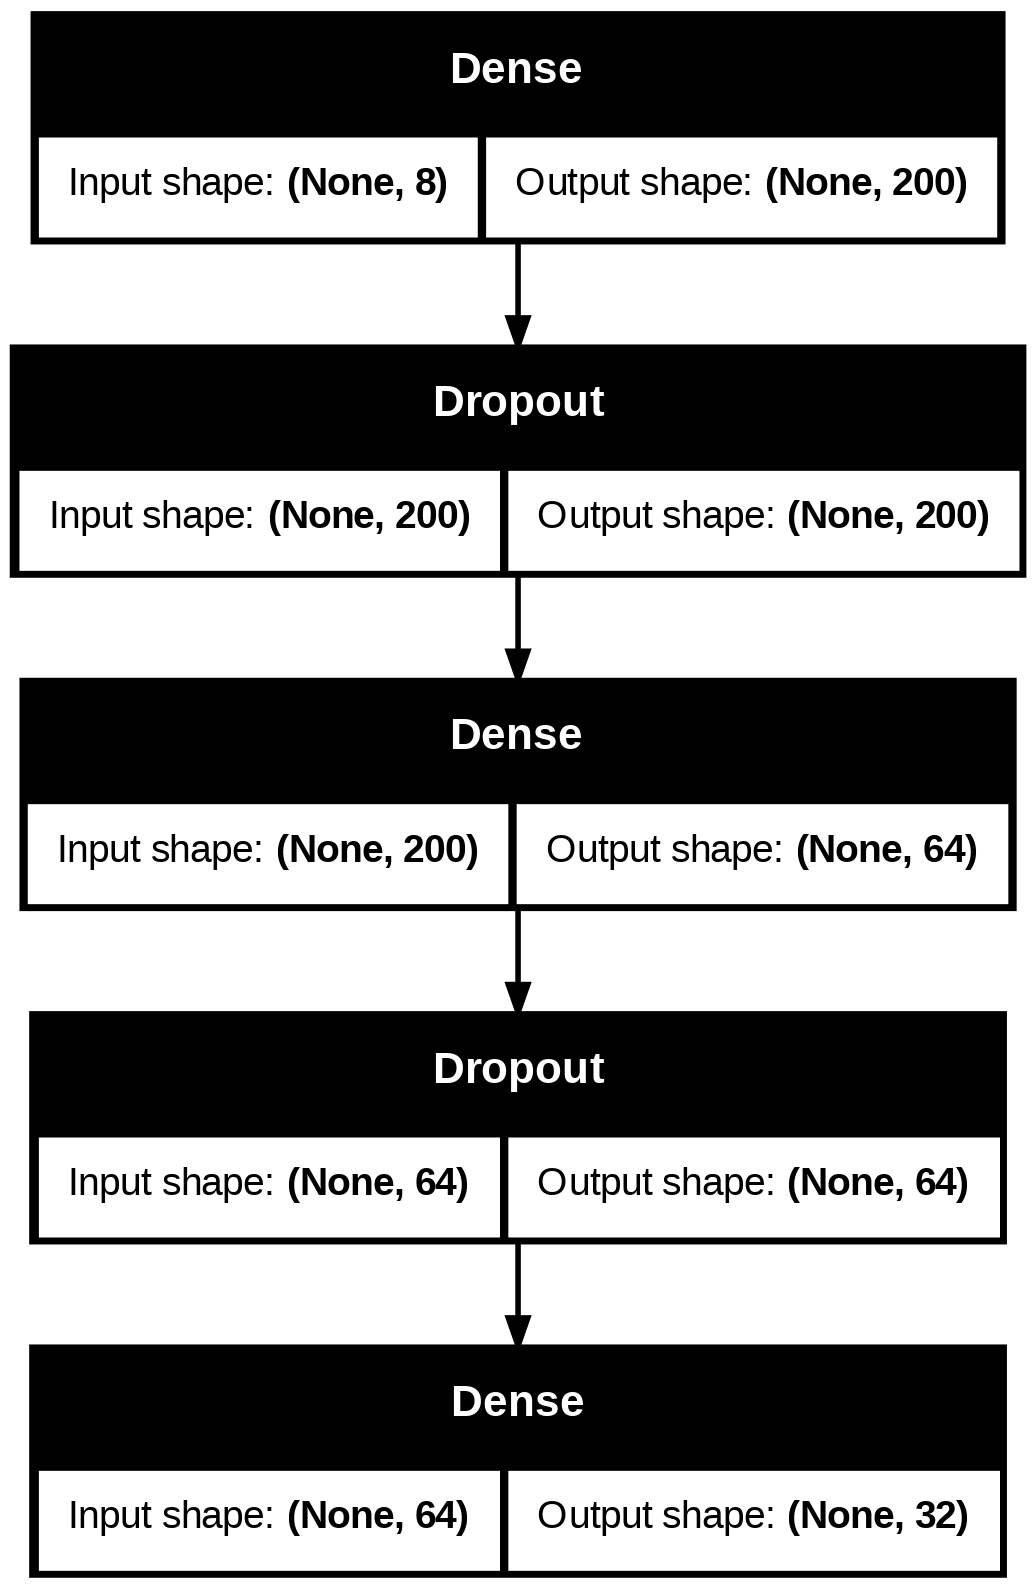

In [20]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [21]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 84.5620 - mae: 8.3761 - val_loss: 21.2663 - val_mae: 3.6985
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.2962 - mae: 3.1248 - val_loss: 5.8643 - val_mae: 1.7805
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.5189 - mae: 1.9416 - val_loss: 5.0050 - val_mae: 1.5786
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.7434 - mae: 1.8498 - val_loss: 4.7195 - val_mae: 1.5363
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0069 - mae: 1.8736 - val_loss: 4.5200 - val_mae: 1.5032
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.6838 - mae: 1.8502 - val_loss: 4.4057 - val_mae: 1.4814
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1466 - mae: 1.8098 - val_loss: 4.5040 - val_mae: 1.4539
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.8138 - mae: 1.7483 - val_loss: 4.2314 - val_mae: 1.4337
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.5371 - ma

# Evaluation

In [22]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6348 - mae: 1.5279 
Akurasi Model: 1.5135
Loss Model: 4.4616


In [23]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

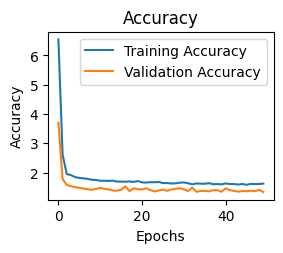

In [24]:
plt.subplot(2, 2, 4)
plt.plot(history.history["mae"], label='Training Accuracy')
plt.plot(history.history['val_mae'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

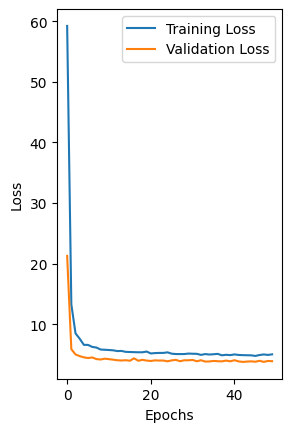

In [25]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


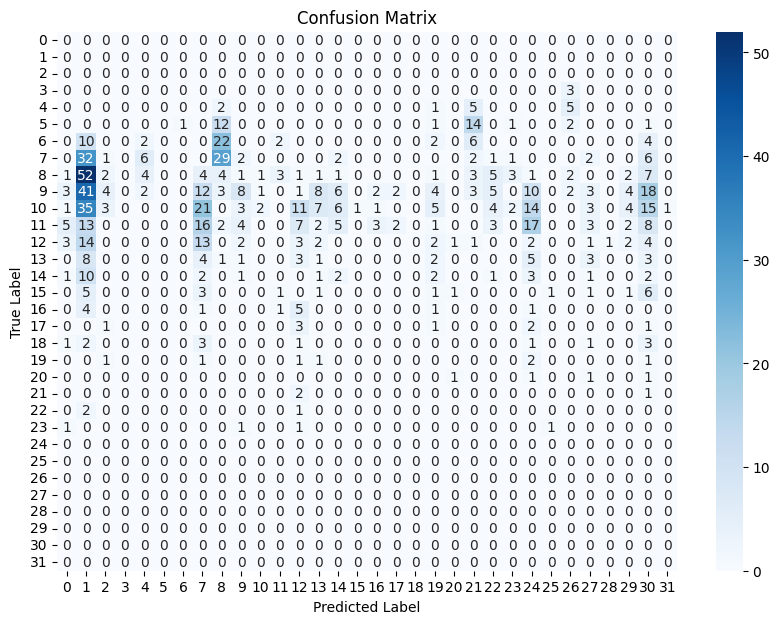

Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       0.00      0.00      0.00         0
         2.0       0.00      0.00      0.00         0
         3.0       0.00      0.00      0.00         3
         4.0       0.00      0.00      0.00        13
         5.0       0.00      0.00      0.00        32
         6.0       0.00      0.00      0.00        48
         7.0       0.00      0.00      0.00        84
         8.0       0.05      0.04      0.05        99
         9.0       0.35      0.06      0.10       142
        10.0       0.50      0.01      0.03       139
        11.0       0.00      0.00      0.00        93
        12.0       0.07      0.06      0.07        51
        13.0       0.04      0.03      0.04        31
        14.0       0.09      0.08      0.08        26
        15.0       0.00      0.00      0.00        21
        16.0       0.00      0.00      0.00        13
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [26]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [27]:
sample_input = np.array([[0, 78, 42 ,42, 20.13, 81.60,	7.62, 262.71]])
sample_input_df = pd.DataFrame(sample_input)

In [28]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:
predicted_age = model.predict(sample_input_scaled)[0][0] # Get the predicted age

print(f"Usia Abalone yang diprediksi: {predicted_age:.2f} tahun (jumlah cincin)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Usia Abalone yang diprediksi: 20.67 tahun (jumlah cincin)


## Save Model

In [30]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('crop_recommendation.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp45dqh9of'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 32), dtype=tf.float32, name=None)
Captures:
  132694316314512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132694316315856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132694316317968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132694316315472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132694316315280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132694316311632: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [33]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']